In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [61]:
df=pd.read_csv('ford.csv')

In [62]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


# Data preprocessing

In [63]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [64]:
df['model'].unique()

array([' Fiesta', ' Focus', ' Puma', ' Kuga', ' EcoSport', ' C-MAX',
       ' Mondeo', ' Ka+', ' Tourneo Custom', ' S-MAX', ' B-MAX', ' Edge',
       ' Tourneo Connect', ' Grand C-MAX', ' KA', ' Galaxy', ' Mustang',
       ' Grand Tourneo Connect', ' Fusion', ' Ranger', ' Streetka',
       ' Escort', ' Transit Tourneo', 'Focus'], dtype=object)

In [65]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [66]:
df=df[df.year<=2022]

In [67]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17965.000000,17965.000000,17965.000000,17965.000000,17965.000000,17965.000000
mean,2016.864069,12279.856833,23360.858447,113.324353,57.907821,1.350804
std,2.024978,4741.279186,19471.182902,62.010410,10.125350,0.432379
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.000000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31048.000000,145.000000,65.700000,1.500000
max,2020.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [68]:
df.duplicated().sum()

154

In [69]:
df=df.drop_duplicates()
df.shape

(17811, 9)

# EDA

<Axes: xlabel='price', ylabel='Count'>

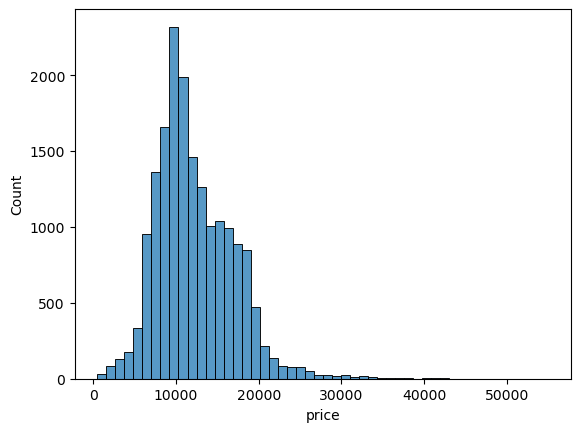

In [70]:
sns.histplot(x='price',data=df,bins=50)

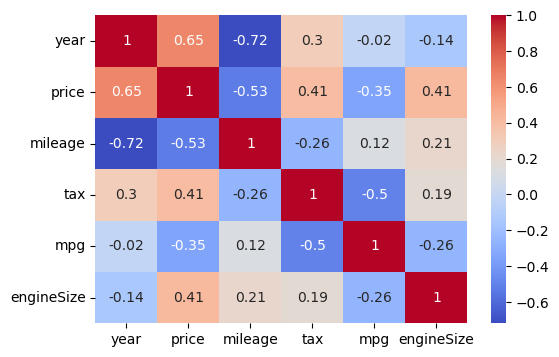

In [71]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()


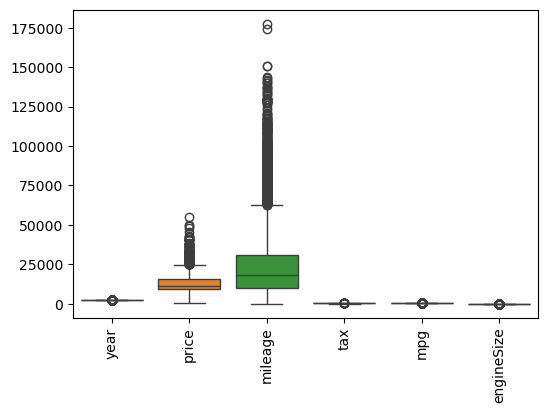

In [72]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df.select_dtypes(include='number'))

plt.xticks(rotation=90)
plt.show()

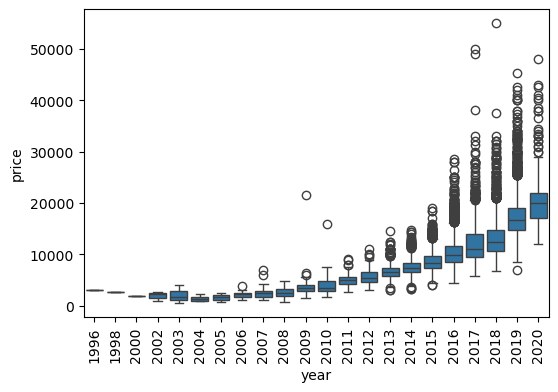

In [73]:
plt.figure(figsize=(6,4))

sns.boxplot(x='year',y='price',data=df)

plt.xticks(rotation=90)
plt.show()

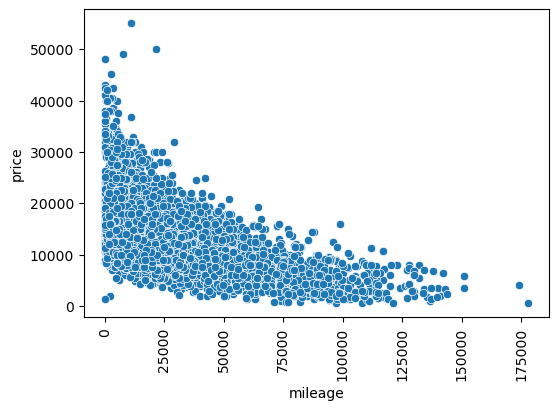

In [74]:
plt.figure(figsize=(6,4))

sns.scatterplot(x='mileage',y='price',data=df)

plt.xticks(rotation=90)
plt.show()

In [75]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

<Axes: xlabel='transmission', ylabel='price'>

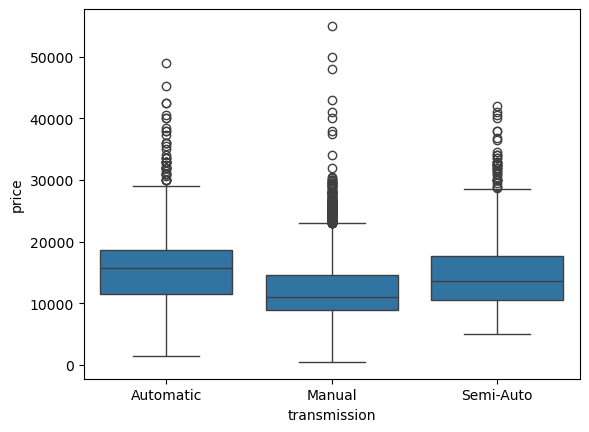

In [76]:
sns.boxplot(data=df,x='transmission',y='price')

<Axes: xlabel='fuelType', ylabel='price'>

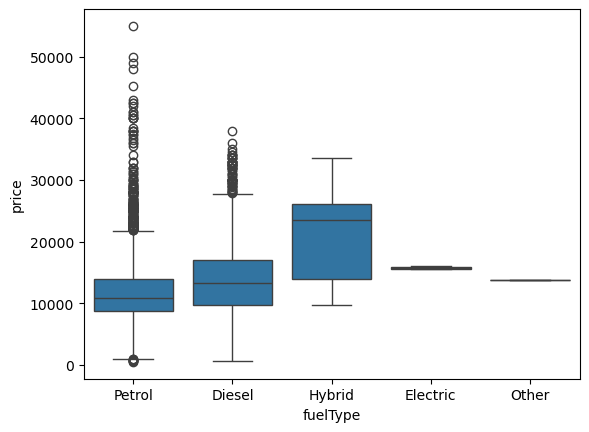

In [77]:
sns.boxplot(data=df,x='fuelType',y='price')

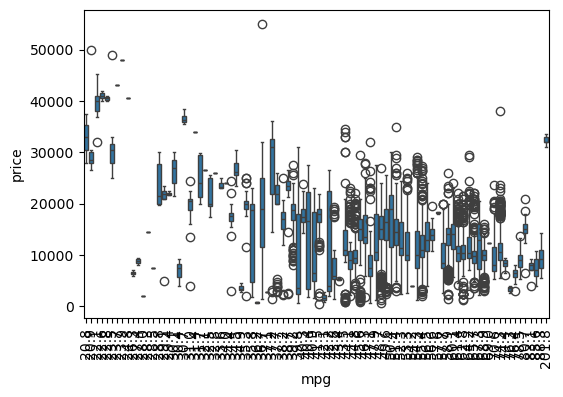

In [78]:
plt.figure(figsize=(6,4))

sns.boxplot(x='mpg',y='price',data=df)

plt.xticks(rotation=90)
plt.show()

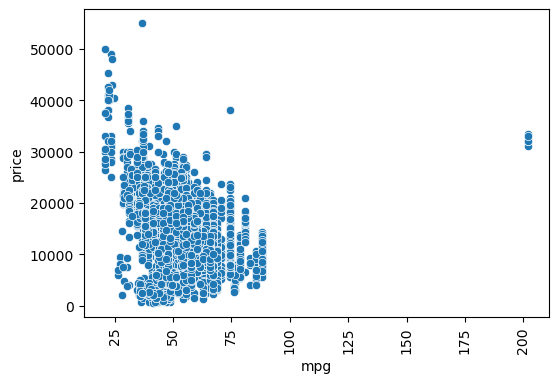

In [79]:
plt.figure(figsize=(6,4))

sns.scatterplot(x='mpg',y='price',data=df)

plt.xticks(rotation=90)
plt.show()

In [80]:
df[df['mpg']>200] ## This is true mileage not an outlier so don't remove this

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
6153,Kuga,2020,31000,Semi-Auto,10,Hybrid,135,201.8,2.5
6536,Kuga,2020,31991,Semi-Auto,2357,Hybrid,135,201.8,2.5
9220,Kuga,2020,32000,Automatic,10,Hybrid,140,201.8,2.5
12862,Kuga,2020,33500,Automatic,5534,Hybrid,140,201.8,2.5
13730,Kuga,2020,32995,Automatic,11,Hybrid,135,201.8,2.5


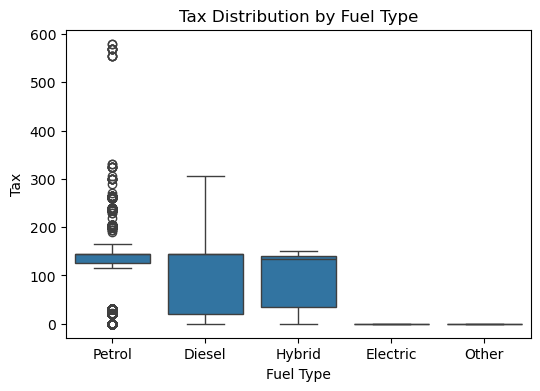

In [81]:

plt.figure(figsize=(6, 4))

sns.boxplot(x='fuelType', y='tax', data=df)

plt.xlabel('Fuel Type')
plt.ylabel('Tax')
plt.title('Tax Distribution by Fuel Type')
plt.show()

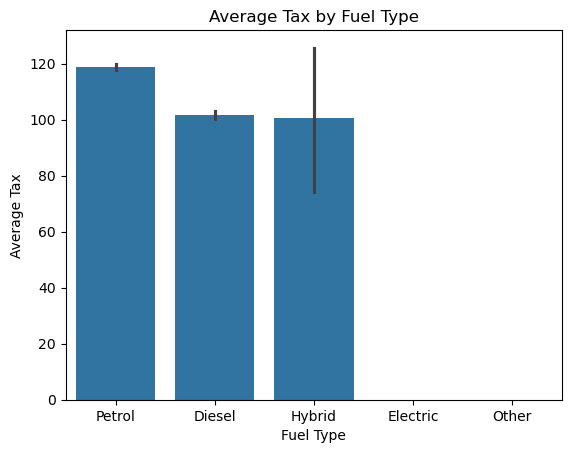

In [82]:
sns.barplot(x='fuelType', y='tax', data=df, estimator='mean')

plt.xlabel('Fuel Type')
plt.ylabel('Average Tax')
plt.title('Average Tax by Fuel Type')
plt.show()

In [83]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

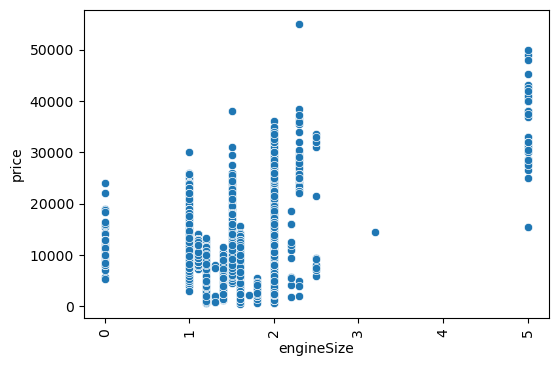

In [84]:
plt.figure(figsize=(6,4))

sns.scatterplot(x='engineSize',y='price',data=df)

plt.xticks(rotation=90)
plt.show()

## Feature Selection

- *model* ---> Keep
- *Year*  ---> keep
- *Transmission*  ---> keep/remove
- *mileage*  ---> keep
- *fueltype*  ---> keep
- *tax*  ---> keep
- *mpg*  ---> keep
- *enginesize*  ---> keep


# Encoding

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17811 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17811 non-null  object 
 1   year          17811 non-null  int64  
 2   price         17811 non-null  int64  
 3   transmission  17811 non-null  object 
 4   mileage       17811 non-null  int64  
 5   fuelType      17811 non-null  object 
 6   tax           17811 non-null  int64  
 7   mpg           17811 non-null  float64
 8   engineSize    17811 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.4+ MB


In [86]:
df['model'].nunique()

24

In [87]:
df = pd.get_dummies(df, columns=['model','transmission','fuelType'], drop_first=True).astype('int')

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17811 entries, 0 to 17965
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   year                          17811 non-null  int32
 1   price                         17811 non-null  int32
 2   mileage                       17811 non-null  int32
 3   tax                           17811 non-null  int32
 4   mpg                           17811 non-null  int32
 5   engineSize                    17811 non-null  int32
 6   model_ C-MAX                  17811 non-null  int32
 7   model_ EcoSport               17811 non-null  int32
 8   model_ Edge                   17811 non-null  int32
 9   model_ Escort                 17811 non-null  int32
 10  model_ Fiesta                 17811 non-null  int32
 11  model_ Focus                  17811 non-null  int32
 12  model_ Fusion                 17811 non-null  int32
 13  model_ Galaxy                 17811 

In [89]:
df

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,150,57,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,14000,9083,150,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,13000,12456,150,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,17500,10460,145,40,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,2019,16500,1482,145,48,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,8999,16700,150,47,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,7499,40700,30,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,9999,7010,20,67,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,8299,5007,145,57,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


# Train Test Split ---> without transmission

In [95]:
x=df.drop(columns=['price','transmission_Manual','transmission_Semi-Auto'],axis=1)
y=df['price']

In [96]:
x

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
17962,2014,40700,30,57,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
17963,2015,7010,20,67,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17964,2018,5007,145,57,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [99]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [100]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
xtrain=scaler.fit_transform(xtrain)
xtest=scaler.transform(xtest)

In [101]:
from sklearn.linear_model import LinearRegression

In [103]:
model=LinearRegression()
model.fit(xtrain,ytrain)

LinearRegression()

In [104]:
ypred=model.predict(xtest)

In [107]:
from sklearn.metrics import r2_score,mean_squared_error

In [108]:
r2=r2_score(ytest,ypred)
rmse=mean_squared_error(ytest,ypred)**0.5

In [109]:
r2

0.8542389184747531

In [110]:
rmse

1808.2301705766413

# Train-Test Split ----> with transmission

In [111]:
x=df.drop(columns=['price'],axis=1)
y=df['price']

In [112]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [113]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
xtrain=scaler.fit_transform(xtrain)
xtest=scaler.transform(xtest)

In [114]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(xtrain,ytrain)
ypred=model.predict(xtest)

In [115]:
r2=r2_score(ytest,ypred)
rmse=mean_squared_error(ytest,ypred)**0.5

In [116]:
r2

0.8549577969667365

In [117]:
rmse

1803.7656575899807

In [118]:
import joblib
joblib.dump(model,'car_price_pred.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [121]:
joblib.dump(x.columns.tolist(), 'feature_columns.pkl')

['feature_columns.pkl']

In [ ]:
pip install streamlit

In [123]:
x.columns

Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model_ C-MAX',
       'model_ EcoSport', 'model_ Edge', 'model_ Escort', 'model_ Fiesta',
       'model_ Focus', 'model_ Fusion', 'model_ Galaxy', 'model_ Grand C-MAX',
       'model_ Grand Tourneo Connect', 'model_ KA', 'model_ Ka+',
       'model_ Kuga', 'model_ Mondeo', 'model_ Mustang', 'model_ Puma',
       'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Electric', 'fuelType_Hybrid',
       'fuelType_Other', 'fuelType_Petrol'],
      dtype='object')

In [124]:
df.columns

Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize', 'model_ C-MAX',
       'model_ EcoSport', 'model_ Edge', 'model_ Escort', 'model_ Fiesta',
       'model_ Focus', 'model_ Fusion', 'model_ Galaxy', 'model_ Grand C-MAX',
       'model_ Grand Tourneo Connect', 'model_ KA', 'model_ Ka+',
       'model_ Kuga', 'model_ Mondeo', 'model_ Mustang', 'model_ Puma',
       'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Electric', 'fuelType_Hybrid',
       'fuelType_Other', 'fuelType_Petrol'],
      dtype='object')

In [ ]:
fuelType = st.selectbox(
    "Fuel Type",
    ["Petrol", "Diesel", "Hybrid"]
)

transmission = st.selectbox(
    "Transmission",
    ["Manual", "Automatic"]
)

model_name = st.selectbox(
    "Model",
    ["A3", "A4", "A5", "A6"]   # use your actual 24 models
)